# PI Meeting — 2026-09-11

**Multi-PEM campaign on RTS-GMLC.** This notebook is the meeting deck: every
figure is generated live from the wave CSVs on branch `d6`, with the
experimental settings spelled out next to each result. Companion docs:
`pi-agenda.md` (decision list), `math-log.md` (derivations),
`19b-contour-results-review.md` (the 4-expert review this presentation
is calibrated against).

**Agenda:** §1 recap of last meeting → §2 what happened since → §3 the
experimental setup → §4 results → §5 the five decisions → §6 anticipated
questions.

## 1. Recap — last PI meeting (2026-08-27)

Three outcomes (recorded in living report §8, math in math-log §1–2):

1. **Derived bidding approved.** The electrolyzer bids its truthful
   opportunity cost, **B = ψ·ρ_H2 = 20·ρ_H2 $/MWh** (ψ = 20 kg H2 per MWh),
   with the cap **ρ_H2 ≤ 2 $/kg** (market ≈ 1). Consequence: the bid is no
   longer a free design variable → the design space halves to **ω-only,
   d = 6** (one PEM-size fraction per tier). Trade-off accepted: ρ_H2
   re-enters the simulation, so each price scenario needs its own runs.
2. **Objective pool expanded** to five grid-level annual deltas: generation
   cost, curtailment, load shedding, **reserve shortfall (new)**, **thermal
   on/off cycling (new)** — final M ≤ 4–5 to be fixed by a correlation
   analysis *(that analysis is today's Decision 1)*.
3. **Study plan:** per-tier size sensitivity sweeps; pairwise contours for
   the largest plants (headline pair 303×317 at 9×9; ρ = 1.5 and 2.0 —
   ρ = 1.0 was added afterwards, so three batches ran); interaction
   heatmaps I_ij.

**Open items from that meeting → status now:**

| Item (08-27) | Status today |
|---|---|
| g4/g5 extraction into summarize | ✅ done; both measured on every wave |
| Load-shed usability (DA-commitment artifact suspicion) | ✅ placebo run: **SPLIT-NEUTRAL** (Δshed −110 MWh at an inert bid) — the retrofit construction adds no artifact; mechanism scope discussed in §4.2 |
| Final M via correlation analysis | ✅ analysis done → **Decision 1 today (M = 4)** |
| g1 cost accounting (nuclear fuel asymmetry) | quantified ($27.8M/yr, nuclear-retrofit runs only; wind clean); convention fix pending — §5 closing item |
| Batch-MOBO implementation (T-M8) | spec'd as prompt 21 (q-ParEGO); starts this week |

## 2. Running log since 08-27

**Directly relevant to today:**

| Date | Event |
|---|---|
| 08-28 | Campaign machinery for the ω-only design built (prompts 17+18): placebo wave, g4/g5 extraction, contour A/B/C + sweep B/C generated; placebo + contour_A submitted to CRC |
| 08-30 | **Placebo verdict: SPLIT-NEUTRAL** — load-shed metric rehabilitated for renewables |
| 08-30 | Screening backfill: all-in retrofit cuts reserve shortfall −90% and fleet startups −2,860/yr |
| 09-06 | **Contour grids complete** (81 × 3 scenarios) and summarized |
| 09-06 | **4-expert adversarial review** of the contour results: all 243 runs pass integrity identities; four story corrections adopted (shown in §4); 9×9 resolution validated by LOOCV |
| 09-10 | **Sweeps complete** (6 tiers × 9 sizes × 2 scenarios) — every planned PCM run is now done; first nuclear data under derived bidding |
| 09-10 | Decision-support computations for today: correlation robustness incl. nuclear, Pareto-front sensitivity to dropping g4, wind-pair interaction index |

**Other activity (context, not today's subject):**

| Date | Event |
|---|---|
| 08-28/29 | Group-meeting deck (KL_Aug_28.pptx) + figures notebook |
| 08-29/30 | CRC home-quota crash killed ~98 mid-flight runs; campaign relocated to group storage; all missing runs resubmitted and recovered. New policy: raw run outputs retained permanently in group storage |
| 09-06/10 | Analysis/figure tooling: contour atlas (HTML + notebook), paper-grade figure specs, execution prompts 20 (analysis package) and 21 (BO benchmark) written and independently reviewed |

## 3. Experimental setup — every knob, stated

**Simulator.** Prescient production-cost model on RTS-GMLC, full year
(366 days, 2020 weather), day-ahead SCUC + real-time SCED, Gurobi with
`threads=1` (bit-reproducible: identical inputs give identical objectives).
~9.7 h wall per run on CRC.

**Retrofit mechanism.** A renewable site with size fraction ω is split into
a normal generator (1−ω share) and a *PEM twin* (ω share) that offers at
B = 20·ρ_H2: hours with LMP ≥ B clear to the grid, hours below divert to
H2 at ψ = 20 kg/MWh. Nuclear uses the thermal-band equivalent (p_min shift
+ cost-curve patch).

**Accounting rules** (the two traps, both handled in `summarize_wave.py`):
1. Prescient books the twin's diverted energy as *curtailment* on the
   `*_PEM` unit → true curtailment excludes `*_PEM` units; the twin's
   curtailment column **is** the H2 series.
2. Prescient charges the twin's cleared (free-fuel) energy at its bid →
   a synthetic cost K_syn = grid sales × B that the base case doesn't have;
   reported cost = raw − K_syn (the **APPROX** column; decomposition shown
   in §4.1).

**Noise model** (two regimes, established during screening): identical
inputs → bit-identical; perturbed inputs → MIP-path noise with floors
±3,000 MWh (shed), ~5,000 MWh (curtailment), ~$0.5M (cost). Reserve
shortfall and starts have no established floor (a replicate study is
Decision 3).

**Objectives** — annual deltas vs the no-PEM base year:

| ID | Metric | Base-year value |
|---|---|---|
| g1 | generation cost (APPROX) | $522.48M |
| g2 | curtailment (`*_PEM` excluded) | 1,688.6 GWh |
| g3 | load shed | 41.50 GWh |
| g4 | reserve shortfall | 203.68 GWh |
| g5 | thermal fleet startups | 5,183 /yr |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from itertools import combinations

plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold',
                     'axes.titleweight': 'bold'})

CAMPAIGN = Path.cwd().parent.parent
assert (CAMPAIGN / 'waves').is_dir(), CAMPAIGN
import sys; sys.path.insert(0, str(CAMPAIGN))
import tiers as T

# design space, read live from the campaign code (not retyped)
tiers_dict = T.build_tiers()[0]
tier_rows = [dict(tier=k, sites=', '.join(v['members']), kind=v['type'],
                  omega_min=v['omega'][0], omega_max=v['omega'][1])
             for k, v in tiers_dict.items()]
display(pd.DataFrame(tier_rows))
print('bid rule: B = %.0f * rho_H2; scenarios %s' % (T.PSI_KG_PER_MWH, T.RHO_SCENARIOS))

,tier,sites,kind,omega_min,omega_max
0,nuclear,121_NUCLEAR_1,thermal,0.05,0.5
1,wind_303,303_WIND_1,renewable,0.05,1.0
2,wind_317,317_WIND_1,renewable,0.05,1.0
3,wind_122,122_WIND_1,renewable,0.05,1.0
4,pv,"319_PV_1, 324_PV_1, 324_PV_2, 324_PV_3",renewable,0.02,0.8
5,tail,"310_PV_2, 320_PV_1, 309_WIND_1",renewable,0.02,1.0


bid rule: B = 20 * rho_H2; scenarios {'A': 1.0, 'B': 1.5, 'C': 2.0}


**Wave inventory** — what was run, at which settings (computed live from
the CSVs so this table cannot drift from the data):

In [2]:
def load(w):
    dm = pd.read_csv(CAMPAIGN / 'waves' / w / 'design_matrix.csv')
    ob = pd.read_csv(CAMPAIGN / 'waves' / w / 'objectives.csv')
    return dm.merge(ob, on='index', suffixes=('', '_o'))

WAVES = {
    'screening':          'per-site OAT + all-in (v2 design, B=40)',
    'placebo':            '317 split at inert bid B=0.01 (artifact control)',
    'contour_303x317_A':  '9x9 wind-pair grid, rho=1.0 (B=20)',
    'contour_303x317_B':  '9x9 wind-pair grid, rho=1.5 (B=30)',
    'contour_303x317_C':  '9x9 wind-pair grid, rho=2.0 (B=40)',
    'sweep_B':            'per-tier OAT, 6 tiers x 9 sizes, rho=1.5',
    'sweep_C':            'per-tier OAT, 6 tiers x 9 sizes, rho=2.0',
}
rows = []
for w, desc in WAVES.items():
    ob = pd.read_csv(CAMPAIGN / 'waves' / w / 'objectives.csv')
    rows.append(dict(wave=w, runs=len(ob), what=desc))
display(pd.DataFrame(rows))
print('total full-year runs across campaign waves:', sum(r["runs"] for r in rows))

,wave,runs,what
0,screening,12,"per-site OAT + all-in (v2 design, B=40)"
1,placebo,1,317 split at inert bid B=0.01 (artifact control)
2,contour_303x317_A,81,"9x9 wind-pair grid, rho=1.0 (B=20)"
3,contour_303x317_B,81,"9x9 wind-pair grid, rho=1.5 (B=30)"
4,contour_303x317_C,81,"9x9 wind-pair grid, rho=2.0 (B=40)"
5,sweep_B,54,"per-tier OAT, 6 tiers x 9 sizes, rho=1.5"
6,sweep_C,54,"per-tier OAT, 6 tiers x 9 sizes, rho=2.0"


total full-year runs across campaign waves: 364


## 4. Results

### 4.1 Cost: the sign flips with hydrogen price — shown honestly

The three-panel decomposition below is the proposed *standard* cost figure
(Decision 4). Read left to right: **raw** system cost rises in every one of
the 243 runs; **K_syn** is the synthetic charge for the twin's cleared free
wind (= grid sales × B, exact identity); **APPROX = raw − K_syn** is the
economically meaningful column, and *there* the ρ = 1.0 surface is uniformly
negative (savings up to 32 M$/yr) while ρ ≥ 1.5 is uniformly positive (up
to +40/+50 M$/yr at B/C).

Mechanism at ρ = 1.0 (review-corrected): the savings come from
**less thermal cycling / de-committed units in surplus hours** — net
delivered renewable actually *falls* vs base, so this is not energy
displacement. The nuclear fuel asymmetry does not touch these wind-only
waves.

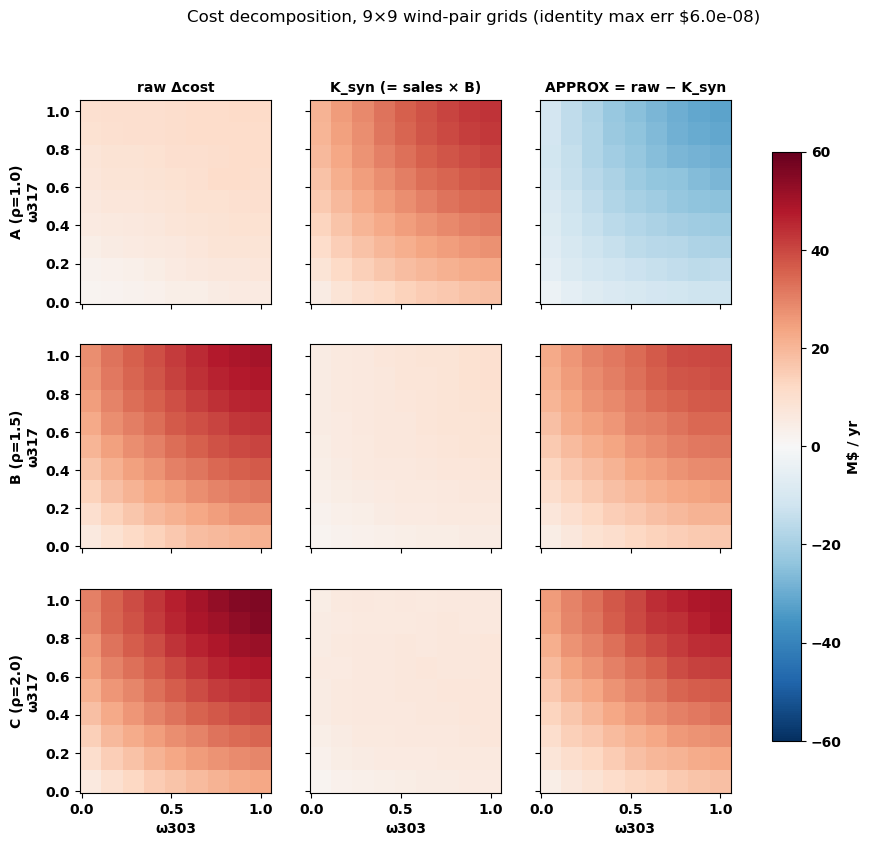

In [3]:
BASE_COST = 522_480_773.81
SCEN = {'A': 1.0, 'B': 1.5, 'C': 2.0}
co = {t: load(f'contour_303x317_{t}') for t in SCEN}

fig, axes = plt.subplots(3, 3, figsize=(10.5, 9), sharex=True, sharey=True)
for i, t in enumerate(SCEN):
    d = co[t]
    panels = [((d.total_cost_raw_usd - BASE_COST) / 1e6, 'raw Δcost'),
              (d.synthetic_bid_cost_usd / 1e6, 'K_syn (= sales × B)'),
              (d.delta_cost_less_synthetic_usd_APPROX / 1e6, 'APPROX = raw − K_syn')]
    for k, (v, ttl) in enumerate(panels):
        Z = d.assign(v=v).pivot(index='wind_317_omega', columns='wind_303_omega', values='v')
        pm = axes[i, k].pcolormesh(Z.columns, Z.index, Z.values, cmap='RdBu_r',
                                   vmin=-60, vmax=60, shading='nearest')
        if i == 0: axes[0, k].set_title(ttl, fontsize=10)
    axes[i, 0].set_ylabel(f'{t} (ρ={SCEN[t]})\nω317')
for k in range(3): axes[2, k].set_xlabel('ω303')
cb = fig.colorbar(pm, ax=axes, shrink=0.85); cb.set_label('M$ / yr')
chk = max((co[t].total_cost_raw_usd - co[t].synthetic_bid_cost_usd
           - co[t].total_cost_less_synthetic_usd).abs().max() for t in SCEN)
fig.suptitle(f'Cost decomposition, 9×9 wind-pair grids (identity max err ${chk:.1e})', fontsize=12)
plt.show()

### 4.2 Reliability: one committed-capacity effect, measured three ways

Load shed, reserve shortfall, and thermal starts all improve, and improve
*more* at higher bids: the higher-priced twin clears less in day-ahead, so
more thermal stays committed. **Scope discipline** (review-enforced): the
placebo certifies only that the retrofit *construction* is artifact-free;
the mechanism at B = 30/40 is *consistent with* conservative-DA, and a
cheap mediation check (DA-cleared twin energy vs B, from existing outputs)
is queued to test it directly. The three metrics are one effect, not three
independent confirmations — which is exactly why they correlate at
r ≥ 0.96 (Decision 1).

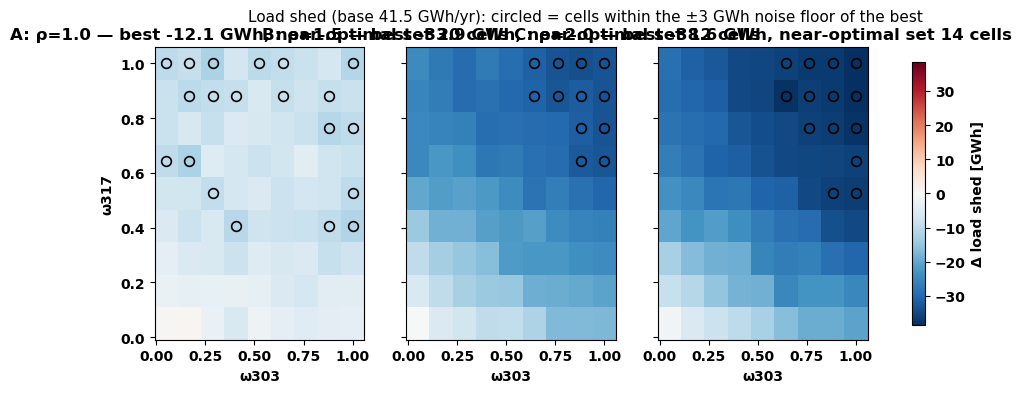

A: shed best -12,109 MWh | reserve best -52,140 MWh | starts best -706/yr
B: shed best -33,870 MWh | reserve best -141,608 MWh | starts best -1,712/yr
C: shed best -38,580 MWh | reserve best -160,461 MWh | starts best -2,245/yr


In [4]:
FLOORS = {'delta_load_shed_mwh': 3000}
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
vmax = max(np.abs(co[t].delta_load_shed_mwh).max() for t in SCEN) / 1e3
norm = matplotlib.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
for ax, t in zip(axes, SCEN):
    d = co[t]
    Z = d.assign(v=d.delta_load_shed_mwh / 1e3).pivot(index='wind_317_omega',
        columns='wind_303_omega', values='v')
    pm = ax.pcolormesh(Z.columns, Z.index, Z.values, norm=norm, cmap='RdBu_r', shading='nearest')
    # near-optimal set (cells within the +-3 GWh floor of the best)
    best = d.delta_load_shed_mwh.min()
    near = d[d.delta_load_shed_mwh <= best + FLOORS['delta_load_shed_mwh']]
    ax.plot(near.wind_303_omega, near.wind_317_omega, 'o', mfc='none', mec='k', ms=7, mew=1.2)
    ax.set_title(f'{t}: ρ={SCEN[t]} — best {best/1e3:.1f} GWh, near-optimal set {len(near)} cells')
    ax.set_xlabel('ω303')
axes[0].set_ylabel('ω317')
cb = fig.colorbar(pm, ax=axes, shrink=0.9); cb.set_label('Δ load shed [GWh]')
fig.suptitle('Load shed (base 41.5 GWh/yr): circled = cells within the ±3 GWh noise floor of the best', fontsize=11)
plt.show()
for t in SCEN:
    d = co[t]
    print(f'{t}: shed best {d.delta_load_shed_mwh.min():,.0f} MWh | reserve best '
          f'{d.delta_reserve_shortfall_mwh.min():,.0f} MWh | starts best {d.delta_thermal_starts.min():,.0f}/yr')

Note the A panel: **20 of 81 cells tie within the noise floor** (including
the all-in corner) — at ρ = 1.0 the shed surface is a broad plateau with no
identifiable optimum location. At B/C the near-optimal set collapses toward
the large-ω corner and the signal is 10×+ the floor.

### 4.3 Curtailment: size-driven, price-insensitive — decomposed honestly

Best point: −1,351 GWh = −80% of base. Two review qualifications: the three
price surfaces differ by ≤ 12% (first-order price-invariant — curtailment
hours clear at LMP ≤ 1, so any bid above ~1 captures them equally), and
**~2/3 of the reduction is the twins absorbing their own base curtailment**
(redirected to H2 — used, not relieved); genuine cross-site relief is
~0.4 TWh.

### 4.4 Sweeps (landed 09-10): marginal value per tier

One-at-a-time size curves for all six tiers. What to see: wind tiers
saturate near ω ≈ 0.8; **nuclear is linear within its 0.05–0.5 box** (no
saturation — its cost panel carries the APPROX warning); curtailment
recovery is ρ-invariant everywhere; the tail cluster is the only place the
two prices visibly diverge in cost.

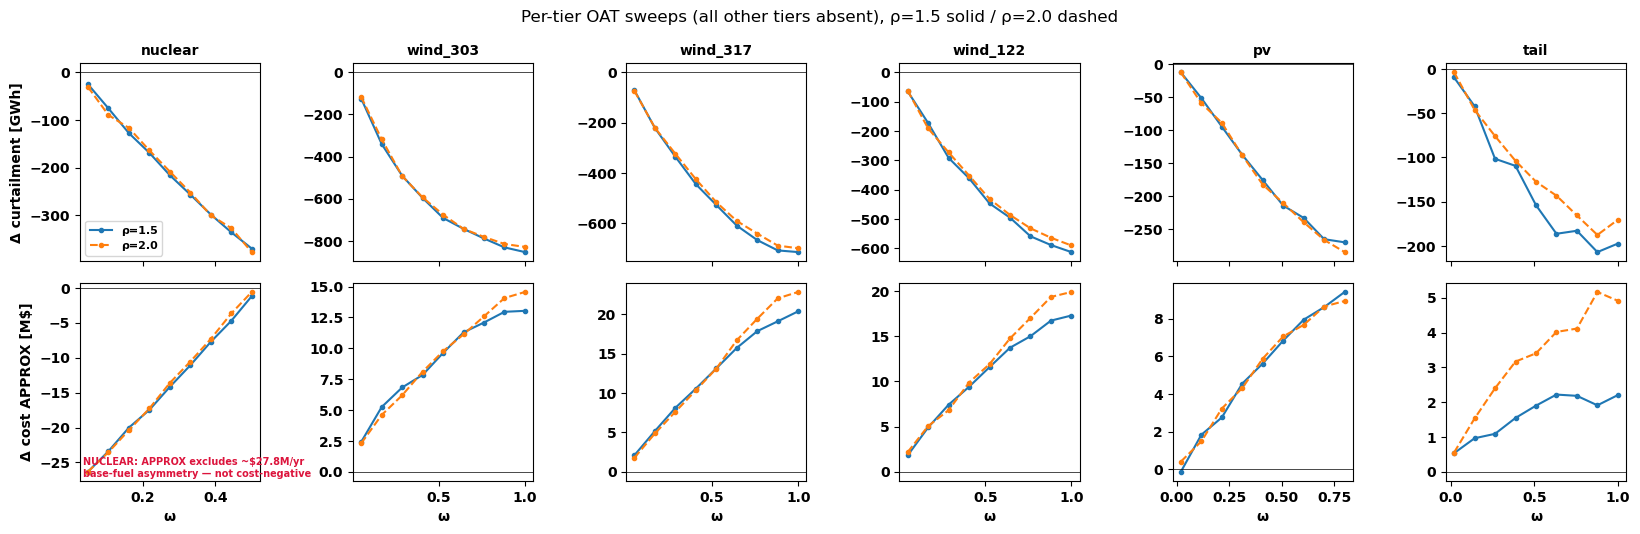

In [5]:
sw = {t: load(f'sweep_{t}') for t in ['B', 'C']}
TIERS = ['nuclear', 'wind_303', 'wind_317', 'wind_122', 'pv', 'tail']
fig, axes = plt.subplots(2, 6, figsize=(16.5, 5.4), sharex='col')
for j, t in enumerate(TIERS):
    for tag, ls in [('B', '-'), ('C', '--')]:
        s = sw[tag]
        r = s[s[f'{t}_omega'].notna()].sort_values(f'{t}_omega')
        axes[0, j].plot(r[f'{t}_omega'], r.delta_curtailment_mwh / 1e3, ls, marker='o', ms=3,
                        label=f'ρ={1.5 if tag == "B" else 2.0}')
        axes[1, j].plot(r[f'{t}_omega'], r.delta_cost_less_synthetic_usd_APPROX / 1e6, ls, marker='o', ms=3)
    axes[0, j].set_title(t, fontsize=10)
    axes[1, j].set_xlabel('ω')
    for a in (axes[0, j], axes[1, j]): a.axhline(0, color='k', lw=0.5)
axes[0, 0].set_ylabel('Δ curtailment [GWh]')
axes[1, 0].set_ylabel('Δ cost APPROX [M$]')
axes[0, 0].legend(fontsize=8)
axes[1, 0].annotate('NUCLEAR: APPROX excludes ~$27.8M/yr\nbase-fuel asymmetry — not cost-negative',
                    xy=(0.02, 0.02), xycoords='axes fraction', fontsize=7, color='crimson')
fig.suptitle('Per-tier OAT sweeps (all other tiers absent), ρ=1.5 solid / ρ=2.0 dashed', fontsize=12)
fig.tight_layout(); plt.show()

### 4.5 Interaction: the wind pair is sub-additive by ~20%

Interaction index at full size, I(1,1) = pair effect − sum of solo effects
(solo curves from the sweeps, pair value from the contour — same scenario,
same lattice). Positive I on all metrics = the sites are **substitutes**:
an additive/separable surrogate would over-predict the pair by ~16–32%.
This is the pair-level confirmation of screening's +54.6% aggregate gap,
and the concrete argument for a full GP (not additive kernel) on the
6-tier space.

In [6]:
rows = []
for tag in ['B', 'C']:
    pair = co[tag][(co[tag].wind_303_omega == 1.0) & (co[tag].wind_317_omega == 1.0)].iloc[0]
    s = sw[tag]
    f303 = s[s.wind_303_omega == 1.0].iloc[0]
    f317 = s[s.wind_317_omega == 1.0].iloc[0]
    for m, scale, unit in [('delta_curtailment_mwh', 1e-3, 'GWh'),
                           ('delta_load_shed_mwh', 1e-3, 'GWh'),
                           ('delta_cost_less_synthetic_usd_APPROX', 1e-6, 'M$'),
                           ('delta_thermal_starts', 1, 'starts')]:
        solo = f303[m] + f317[m]
        I = pair[m] - solo
        rows.append(dict(scenario=tag, metric=f'{m} [{unit}]',
                         pair=round(pair[m] * scale, 1), solo_sum=round(solo * scale, 1),
                         I=round(I * scale, 1), I_pct_of_sum=f'{100 * I / abs(solo):+.0f}%'))
display(pd.DataFrame(rows))

,scenario,metric,pair,solo_sum,I,I_pct_of_sum
0,B,delta_curtailment_mwh [GWh],-1243.7,-1568.2,324.5,+21%
1,B,delta_load_shed_mwh [GWh],-33.4,-41.7,8.3,+20%
2,B,delta_cost_less_synthetic_usd_APPROX [M$],40.1,33.4,6.7,+20%
3,B,delta_thermal_starts [starts],-1712.0,-2091.0,379.0,+18%
4,C,delta_curtailment_mwh [GWh],-1215.3,-1528.3,313.1,+20%
5,C,delta_load_shed_mwh [GWh],-38.6,-48.3,9.7,+20%
6,C,delta_cost_less_synthetic_usd_APPROX [M$],49.6,37.4,12.1,+32%
7,C,delta_thermal_starts [starts],-2245.0,-2682.0,437.0,+16%


## 5. The five decisions (details: `pi-agenda.md`)

### D1 — Fix M = 4: drop reserve shortfall from the objective vector

{shed, reserve, starts} are one committed-capacity cluster; reserve is the
middle metric, maximally correlated with everything. Two robustness checks
computed below, live: (i) the cluster survives adding the nuclear/all-tier
sweep data; (ii) dropping g4 barely changes the non-dominated set.
**Ask: sign-off on M = 4 = {cost, curtailment, shed, starts}, reserve
reported as diagnostic.** (Fallback: keep g4, drop g5 — loses the only
equipment-wear proxy.)

In [7]:
M5 = ['delta_cost_less_synthetic_usd_APPROX', 'delta_curtailment_mwh',
      'delta_load_shed_mwh', 'delta_reserve_shortfall_mwh', 'delta_thermal_starts']
M4 = [m for m in M5 if m != 'delta_reserve_shortfall_mwh']

print('(i) reliability-cluster Spearman, pooled sweep+contour (n=135/scenario):')
for tag in ['B', 'C']:
    both = pd.concat([sw[tag][M5], co[tag][M5]])
    print(f'  {tag}: shed-resv {both[M5[2]].corr(both[M5[3]], method="spearman"):+.3f}'
          f' | resv-starts {both[M5[3]].corr(both[M5[4]], method="spearman"):+.3f}'
          f' | resv-cost {both[M5[3]].corr(both[M5[0]], method="spearman"):+.3f}')

def pareto_idx(X):
    return {i for i in range(len(X))
            if not any(np.all(X[j] <= X[i]) and np.any(X[j] < X[i])
                       for j in range(len(X)) if j != i)}

print('\n(ii) Pareto-front sensitivity to dropping g4 (81-cell grids):')
for tag in SCEN:
    p5 = pareto_idx(co[tag][M5].values)
    p4 = pareto_idx(co[tag][M4].values)
    print(f'  {tag}: 5-obj front {len(p5)} | 4-obj front {len(p4)} |'
          f' dropped {len(p5 - p4)} | added {len(p4 - p5)}')

(i) reliability-cluster Spearman, pooled sweep+contour (n=135/scenario):


  B: shed-resv +0.975 | resv-starts +0.988 | resv-cost -0.982
  C: shed-resv +0.983 | resv-starts +0.993 | resv-cost -0.985

(ii) Pareto-front sensitivity to dropping g4 (81-cell grids):
  A: 5-obj front 16 | 4-obj front 15 | dropped 1 | added 0
  B: 5-obj front 75 | 4-obj front 71 | dropped 4 | added 0
  C: 5-obj front 76 | 4-obj front 73 | dropped 3 | added 0


### D2 — Stage-2 BO scope + budget

At ρ = 1.0 the objectives are *aligned* — computed below: the all-in corner
weakly dominates most of the grid, so there is nothing for a
multi-objective optimizer to trade off there. **Ask: full q-ParEGO MOBO at
ρ = 1.5 and 2.0 (≈ 545 core-h each); for ρ = 1.0 only the n₀ = 16 Sobol
batch in the full 6-D space as an alignment sanity check (the alignment
evidence is pair-grid; we verify in 6-D before skipping). Total ≈ 1,250
core-h.**

In [8]:
for tag in SCEN:
    d = co[tag]
    corner = d[(d.wind_303_omega == 1.0) & (d.wind_317_omega == 1.0)][M5].values[0]
    dominated = sum(1 for x in d[M5].values
                    if np.all(corner <= x) and np.any(corner < x))
    r = d[M5[1]].corr(d[M5[0]], method='spearman')
    print(f'{tag} (ρ={SCEN[tag]}): corner (1,1) weakly dominates {dominated}/81 cells'
          f' | curt-cost Spearman {r:+.2f}')

A (ρ=1.0): corner (1,1) weakly dominates 53/81 cells | curt-cost Spearman +0.99
B (ρ=1.5): corner (1,1) weakly dominates 0/81 cells | curt-cost Spearman -0.98
C (ρ=2.0): corner (1,1) weakly dominates 0/81 cells | curt-cost Spearman -0.98


### D3 — Replicate/noise study (~300–500 core-h)

All ± claims rest on the two-regime noise model plus one placebo run. The
adversarial review's standing demand: 3–5 perturbed replicates at base +
3–4 grid points per scenario → empirical error bars on every headline.
CRC is idle. **Ask: approve the compute.**

### D4 — Standard cost figure

**Ask: adopt the §4.1 three-panel decomposition as the paper's standard
cost figure** (the sign-flip headline is never shown without its
accounting).

### D5 — Disclosure: settlement anomaly (site NPV frozen)

Realized revenue per MWh sold is often below the bid — computed below.
DA-clears-at-bid / RT-settles-lower behavior. Grid-level objectives are
unaffected, but the "B* is profit-maximizing ⇒ revenue ≥ B·sales" step of
the site-NPV construction doesn't hold under this settlement. **Site NPV
is frozen until the convention is documented.** Flagging today so it never
surprises in a draft.

In [9]:
for tag in SCEN:
    sd = pd.read_csv(CAMPAIGN / 'waves' / f'contour_303x317_{tag}' / 'site_detail.csv')
    sd = sd[sd.pem_grid_sales_mwh > 0]
    rev = sd.site_market_revenue_usd / sd.pem_grid_sales_mwh
    print(f'{tag} (B={20 * SCEN[tag]:.0f}): realized $/MWh sold — median {rev.median():.1f},'
          f' min {rev.min():.1f}, negative rows {int((rev < 0).sum())}/{len(rev)}')

A (B=20): realized $/MWh sold — median 9.2, min -48.6, negative rows 16/162
B (B=30): realized $/MWh sold — median 54.4, min -259.0, negative rows 9/162
C (B=40): realized $/MWh sold — median 81.4, min -304.3, negative rows 6/162


## 6. Anticipated questions

**"Does the g4 correlation hold with nuclear in the design?"** Yes —
§5/D1(i) pools all six tiers: cluster r ≥ 0.975. The nuclear-only
sub-sample (n = 9) is noisier (shed–reserve +0.18 at ρ = 1.5), but those
shed deltas sit at the noise floor where rank correlation is meaningless.

**"Does dropping g4 change the front?"** §5/D1(ii): 1/4/3 points out of
16/75/76 — nothing added.

**"Which acquisition at M = 4?"** q-ParEGO (doc-16 Decision 2, option b —
no hard constraint); M = 4 keeps qLogNEHVI viable as a robustness check.

**"If raw cost rises in every run, isn't the saving your correction?"**
The correction is an exact identity (K_syn = sales × B, err < $1) fixing a
charge the base case cannot have; both columns are always shown (§4.1);
and the sign at ρ ≥ 1.5 is robust in *both* columns.

**"−93% shed on a 41.5 GWh base — real?"** Within the model, yes at C
(signal 13× the floor); at A the surface is a plateau (§4.2) and we say so.
Base shed comes from a handful of scarcity periods in one weather year —
the replicate study (D3) and absolute-GWh reporting are the guardrails.

**"Why not just commit more thermal for reliability instead of paying
+50 M$?"** Fair — the +50M buys hydrogen (≈ 85 Mkg at C ≈ 169 M$ at ρ = 2);
reliability is a by-product, and the paper will benchmark against a
conventional lever before calling it a dividend. (Referee-review demand,
on the roadmap.)

## 7. If approved today

Prompt 20 (sweep analysis + paper figures + mediation extraction) and
prompt 21 (Stage-1 BO replay + q-ParEGO) run this week; D3 replicates
submitted to CRC; Stage-2 waves generated per D2 scope. Next check-in with
Stage-1 replay results + formal figures.